# Неделя 3. Понедельник

## Обучение без учителя

In [171]:
from umap import UMAP
import matplotlib.pyplot as plt
import numpy as np
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import rand_score, silhouette_score, calinski_harabasz_score, homogeneity_score, completeness_score

0️⃣ Реализуй функцию, вычисляющую евклидово расстояние между двумя векторами, представленными списками. 

In [172]:
def compute_l2(a: list, b: list) -> float:
    a = np.array(a)
    b = np.array(b)
    distance = np.sqrt(np.sum(np.power(a - b, 2)))
    return distance


### Кластеризация

### Задание 1

Импортируйте несколько моделей кластеризации: 
* KMeans
* DBSCAN
* https://scikit-learn.org/stable/modules/clustering.html

In [180]:
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
import pandas as pd

Импортируй датасет: `path = 'aux/X_train.txt'`

В этом файле содержатся датчики мобильного телефона для различных активностей пользователя. Необходимо выявить какие кластеры можно выделить в данных и предположить, каким состояниями они соответствуют (пользователь в покое, идет, сидит и тд.)

In [181]:
path = 'aux/X_train.txt'

In [182]:
df = pd.read_csv(path, sep='\s+', header=None)
y = pd.read_csv('aux/y_train.txt', header=None, names=['target'])

ss = StandardScaler()

In [183]:
#df = pd.DataFrame(ss.fit_transform(df), columns=df.columns)

1. Примени ряд кластеризационных [моделей](https://scikit-learn.org/stable/modules/clustering.html) на импортированном датасете. Обязательно визуализируй результат (выбери 3-4 столбца из датасета, отразите их на `scatterplot`, задай в качестве цвета маркеров лейблы кластеров). 

In [184]:
km = KMeans(6)
ag = AgglomerativeClustering(n_clusters=6)
dbs = DBSCAN(eps=8.1)

In [185]:
km.fit(df)
ag.fit(df)
dbs.fit(df)

DBSCAN(eps=8.1)

In [186]:
n_clusters_list = np.arange(2, 8)

for n_clusters in n_clusters_list:
    km = KMeans(n_clusters=n_clusters)
    km.fit(df)
    print(f'при n_clusters={n_clusters}, silhouette_score:{silhouette_score(df, km.labels_)}')

при n_clusters=2, silhouette_score:0.48515412206804054
при n_clusters=3, silhouette_score:0.3318890342911535
при n_clusters=4, silhouette_score:0.18722388778315635
при n_clusters=5, silhouette_score:0.17073589463689737
при n_clusters=6, silhouette_score:0.14483972121056007
при n_clusters=7, silhouette_score:0.12836420070084278


2. Определи и зафиксируй количество кластеров, которое наиболее оптимально с точки зрения метрики `silhouette`. Установи библиотеку [`yellowbrick`](https://www.scikit-yb.org/en/latest/api/cluster/silhouette.html) и визуализируй результаты для использованных методов (при использовании метода K-means). 

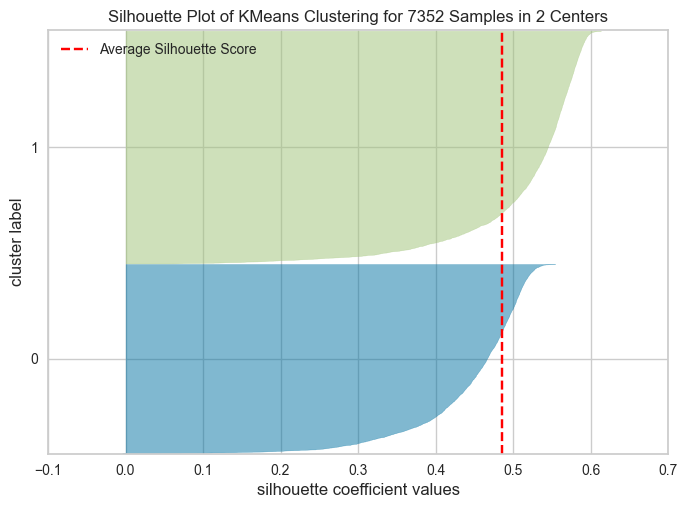

In [187]:
model = KMeans(n_clusters=2)
visualizer = SilhouetteVisualizer(estimator=model, colors='yellowbrick')
visualizer.fit(df)
    
visualizer.show();

# ❓

Почему метрика `silhouette` может быть бессмысленной в некоторых случаях? Приведи пример такой ситуации. 

_В ситуациях, когда кластеры разделены не линейно, например, а перекрывают друг друга, один вложен в другой, это может плохо повлиять на метрику_

3. Вычисли произвольные дополнительную метрику: [Calinski-Harabasz Index](https://scikit-learn.org/stable/modules/clustering.html#calinski-harabasz-index). 

In [188]:
print(f'Метрика Калински - {calinski_harabasz_score(df, visualizer.labels_)}')

Метрика Калински - 9817.650955125646


# ❓ 
* Объясни своими словами, что вычисляет эта метрика? Какое у нее худшее и лучшее значение?

_Метрика показывает отношение межгрупповой дисперсии к внутригрупповой дисперсии. Чем она больше, тем лучше. Самое плохое значение стремится к нулю. Но это условность, такого достичь трудно. Эта метрика скорее нужна для выбора лучшего алгоритма кластеризации, а не для интерпретации результата_

4. Примените [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [UMAP](https://umap-learn.readthedocs.io/en/latest/) и [tSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) декомпозиции и визуализируйте полученные объекты в новом (двумерном или трехмерном) пространстве. В процессе перебирайте возможные параметры и сравнивайте результат по визуализациям.

In [189]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

In [246]:
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=45)
tsne_3d = TSNE(n_components=3)
ump = UMAP(n_components=2, n_neighbors=75)

In [247]:
%time
x_pca = pca.fit_transform(df)

CPU times: user 4 µs, sys: 3 µs, total: 7 µs
Wall time: 26 µs


In [248]:
%time
x_tsne = tsne.fit_transform(df)

CPU times: user 2 µs, sys: 2 µs, total: 4 µs
Wall time: 9.06 µs


In [249]:
%time
x_umap = ump.fit_transform(df)

CPU times: user 9 µs, sys: 6 µs, total: 15 µs
Wall time: 19.3 µs


5. Повтори шаги 1 и 2 для трансформированных данных. 

In [250]:
X = {
    'pca'  : x_pca,
    'tsne' : x_tsne,
    'umap' : x_umap
}

models = {
    'KMeans' : KMeans(3),
    'AggCls' : AgglomerativeClustering(3),
    'DBSCAN' : DBSCAN(eps=1)
}

In [251]:
def plot_results(X: dict, models: dict):
    fig, ax = plt.subplots(3, 3, figsize=(12, 12))
    for i in np.arange(3):
        for j in np.arange(3):
            X_ = list(X.values())[i]
            model = list(models.values())[j].fit(X_)
            colors = model.labels_
            sil_score = silhouette_score(X_, model.labels_)
#            
            ax[i, j].scatter(X_[:, 0], X_[:, 1], c=colors, marker='.', s=10, cmap='viridis')
            ax[i, j].set_title(f'{list(X.keys())[i]}/{list(models.keys())[j]}: sil_score={sil_score:.3f}')

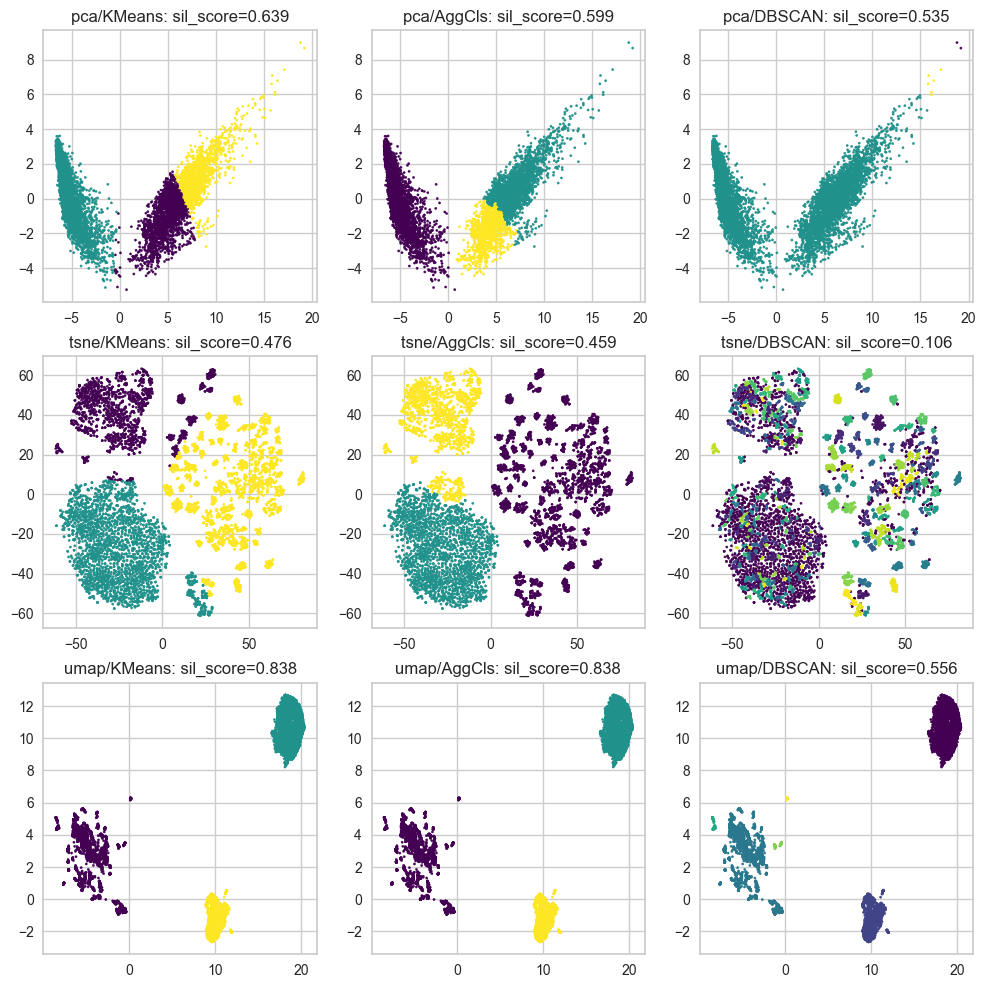

In [252]:
plot_results(X, models)

6. Сделай вывод: какой метод кластеризации и какие преобразования данных дают наилучший результат. 

_Если смотреть просто на метрику Силуэта, то самый удачный вариант umap + dbscan. Однако, создается впечатление, что кластеров именно 3_

7. Визуализируй наиболее успешный результат и попробуй интерпретировать кластеры: почему объекты сгруппировались именно так?

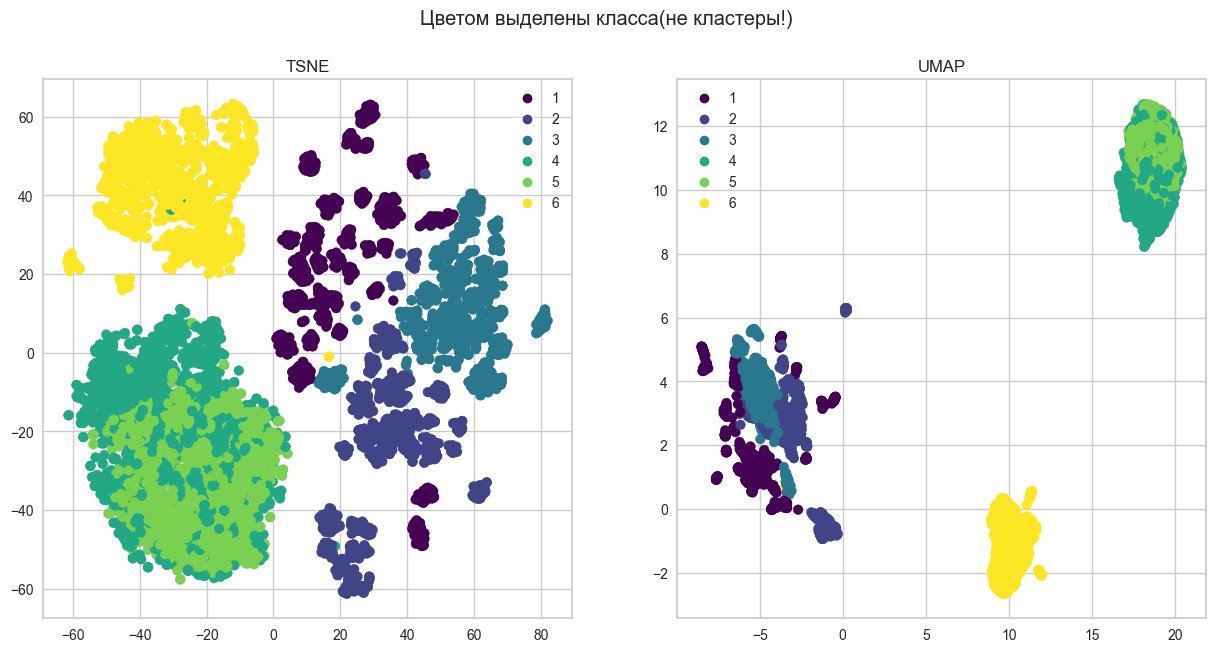

In [258]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

scatter_tsne = ax[0].scatter(x_tsne[:, 0], x_tsne[:, 1], c=y.to_numpy(), cmap='viridis', label=y.to_numpy().ravel())
scatter_umap = ax[1].scatter(x_umap[:, 0], x_umap[:, 1], c=y.to_numpy(), cmap='viridis', label=y.to_numpy().ravel())

# Получение уникальных меток
unique_labels = np.unique(y)

# Добавление каждой точки в легенду с её меткой
legend_elements = []
for label in unique_labels:
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(label)), label=label))

# Включение легенды с кастомными элементами
ax[0].legend(handles=legend_elements)
ax[1].legend(handles=legend_elements)
fig.suptitle('Цветом выделены класса(не кластеры!)')
ax[0].set_title('TSNE');
ax[1].set_title('UMAP');

_Ощущение, что tsne разделил их поинтереснее_

In [262]:
km = KMeans(6)
km.fit(x_tsne)


my_rand_score = rand_score(y.to_numpy().ravel(), km.labels_)
my_homogeneity_score = homogeneity_score(y.to_numpy().ravel(), km.labels_)
my_completeness_score = completeness_score(y.to_numpy().ravel(), km.labels_)

print('Внешние метрики - ', my_rand_score, my_homogeneity_score, my_homogeneity_score)

Внешние метрики -  0.9142889000171562 0.7606299770250353 0.7606299770250353


_Достаточно высокие внешние метрики, но ради интереса проверим еще понижение до 3 размерностей_

#### Понжение до 3D

In [263]:
x_tsne3 = tsne_3d.fit_transform(df)

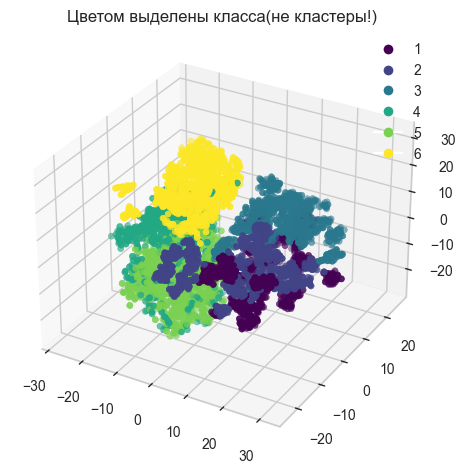

In [264]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Создание scatter plot
scatter = ax.scatter(x_tsne3[:, 0], x_tsne3[:, 1], x_tsne3[:, 2], c=y, cmap='viridis')


# Получение уникальных меток
unique_labels = np.unique(y)

# Добавление каждой точки в легенду с её меткой
legend_elements = []
for label in unique_labels:
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(label)), label=label))

# Включение легенды с кастомными элементами
plt.legend(handles=legend_elements)
plt.title('Цветом выделены класса(не кластеры!)');




In [265]:
km = KMeans(6)
km.fit(x_tsne3)


my_rand_score = rand_score(y.to_numpy().ravel(), km.labels_)
my_homogeneity_score = homogeneity_score(y.to_numpy().ravel(), km.labels_)
my_completeness_score = completeness_score(y.to_numpy().ravel(), km.labels_)

my_rand_score, my_homogeneity_score, my_homogeneity_score

(0.8972550646733088, 0.7098690343252332, 0.7098690343252332)

<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Пора закоммить изменения в файле. Сделай это с сообщением: 
`"Clustering: task 1 finished"`

После коммита выполни `!git status` в ячейке ниже. 